In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeClassifier

from decision_tree import find_best_split, DecisionTree

# testing `find_best_split`

In [2]:
data = pd.read_csv("students.csv")
data.sample(10)

,STG,SCG,STR,LPR,PEG,UNS
81,0.30,0.25,0.26,0.12,0.67,1
140,0.33,0.04,0.50,0.55,0.10,0
83,0.25,0.29,0.15,0.48,0.26,0
115,0.29,0.64,0.18,0.61,0.45,1
23,0.18,0.31,0.32,0.42,0.28,0
65,0.25,0.10,0.03,0.09,0.15,0
166,0.34,0.40,0.38,0.20,0.61,1
141,0.42,0.15,0.66,0.78,0.40,1
127,0.27,0.76,0.80,0.28,0.28,0
194,0.60,0.14,0.22,0.11,0.66,1


In [3]:
X = data.drop(columns="UNS").to_numpy()
y = data["UNS"].to_numpy()

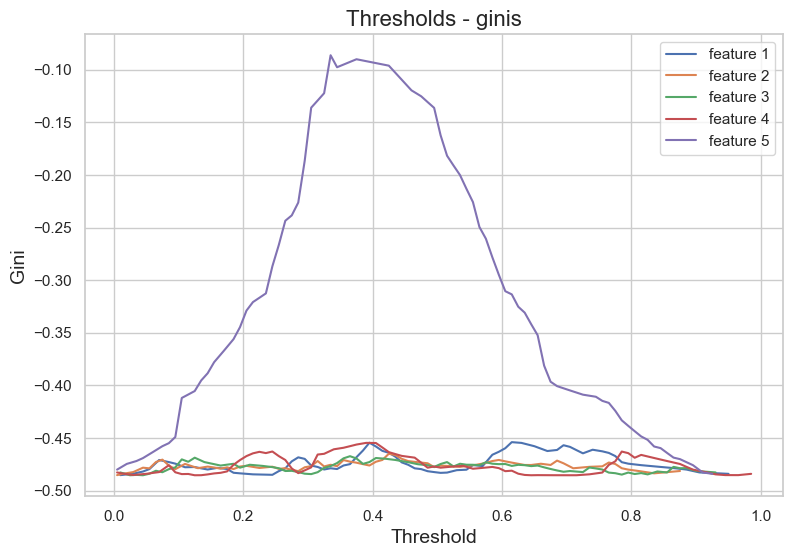

In [4]:
plt.figure(figsize=(9, 6))

for feature in range(X.shape[1]):
    thresholds, ginis, best_threshold, best_gini = find_best_split(X[:, feature], y)
    plt.plot(thresholds, ginis, label=f"feature {feature+1}")

plt.title("Thresholds - ginis", fontsize=16)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Gini", fontsize=14)

plt.legend()
plt.show()

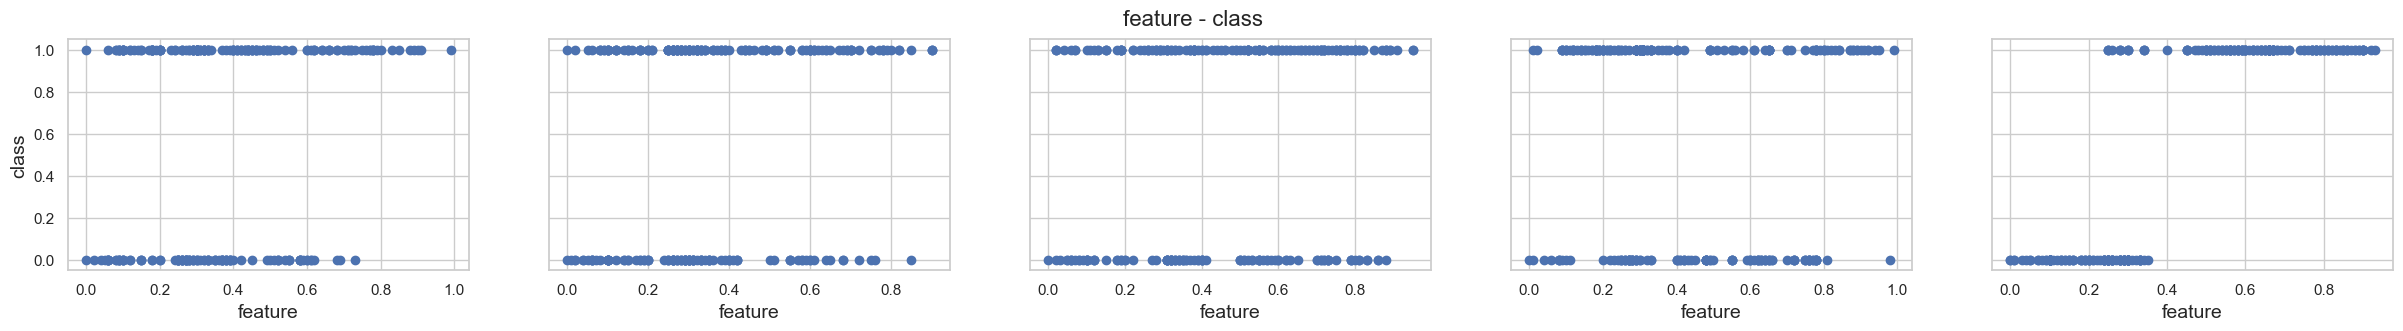

In [5]:
fig, axs = plt.subplots(1, 5, figsize=(30, 3), sharey=True)

plt.suptitle("feature - class", fontsize=16)
axs[0].set_ylabel("class", fontsize=14)

for feature in range(X.shape[1]):
    axs[feature].scatter(X[:, feature], y)
    axs[feature].set_xlabel("feature", fontsize=14)
    
plt.show()

# testing `DecisionTree`

In [6]:
data = pd.read_csv("agaricus-lepiota.data")
data.sample(10)

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
5420,e,x,s,e,t,n,f,c,b,w,...,s,w,e,p,w,t,e,w,c,w
2194,e,x,y,e,t,n,f,c,b,n,...,s,g,w,p,w,o,p,n,v,d
1601,e,f,f,w,f,n,f,w,b,k,...,f,w,w,p,w,o,e,n,s,g
1643,e,f,f,w,f,n,f,w,b,n,...,s,w,w,p,w,o,e,n,s,g
6552,p,f,s,n,f,s,f,c,n,b,...,k,p,p,p,w,o,e,w,v,d
5759,p,f,s,p,t,n,f,c,b,g,...,s,w,w,p,w,t,p,r,v,g
717,e,x,y,n,t,a,f,c,b,n,...,y,w,w,p,w,o,p,n,s,g
6371,p,f,y,n,f,f,f,c,n,b,...,s,w,w,p,w,o,e,w,v,l
3402,p,x,s,p,f,c,f,c,n,p,...,s,w,w,p,w,o,p,k,v,d
5485,p,x,y,g,f,f,f,c,b,p,...,k,p,p,p,w,o,l,h,y,p


In [7]:
X = data.drop(columns="p").to_numpy()
y = LabelEncoder().fit_transform(data["p"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True, random_state=42)

In [8]:
model = DecisionTree(feature_types=["categorical"] * X.shape[1])
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(f"Accuracy = {accuracy_score(y_test, pred)}")

Accuracy = 1.0


Если хотим кросс валидацию

In [9]:
class WrappedDecisionTree(BaseEstimator):

    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        self.feature_types = feature_types
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

        self._model = DecisionTree(
            feature_types=self.feature_types,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf
        )

    def fit(self, X, y):
        self._model.fit(X, y)
        return self

    def predict(self, X):
        return self._model.predict(X)

In [10]:
model = WrappedDecisionTree(feature_types=["categorical"] * X.shape[1])
cross_val_score(model, X, y, scoring="accuracy", cv=10, n_jobs=-1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# testing cross validation with sklearn

In [11]:
data = pd.read_csv("tic-tac-toe.data")
data.sample(10)

,x,x.1,x.2,x.3,o,o.1,x.4,o.2,o.3,positive
353,o,x,b,o,x,b,x,x,o,positive
707,x,b,x,o,x,x,o,o,o,negative
781,o,x,o,o,x,x,o,b,x,negative
506,b,x,o,o,x,b,b,x,b,positive
85,x,x,o,o,x,x,o,x,o,positive
611,b,b,o,x,x,x,b,o,b,positive
142,x,o,x,b,b,x,o,o,x,positive
794,o,x,b,o,o,x,x,x,o,negative
716,x,b,o,x,x,o,o,x,o,negative
541,b,o,x,o,x,b,x,b,b,positive


In [12]:
X = data.drop(columns="positive").to_numpy()
y = LabelEncoder().fit_transform(data["positive"])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y,
)

In [19]:
pg = {
    "max_depth": [1, 3, 5, 7],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 3, 5, 7]
}

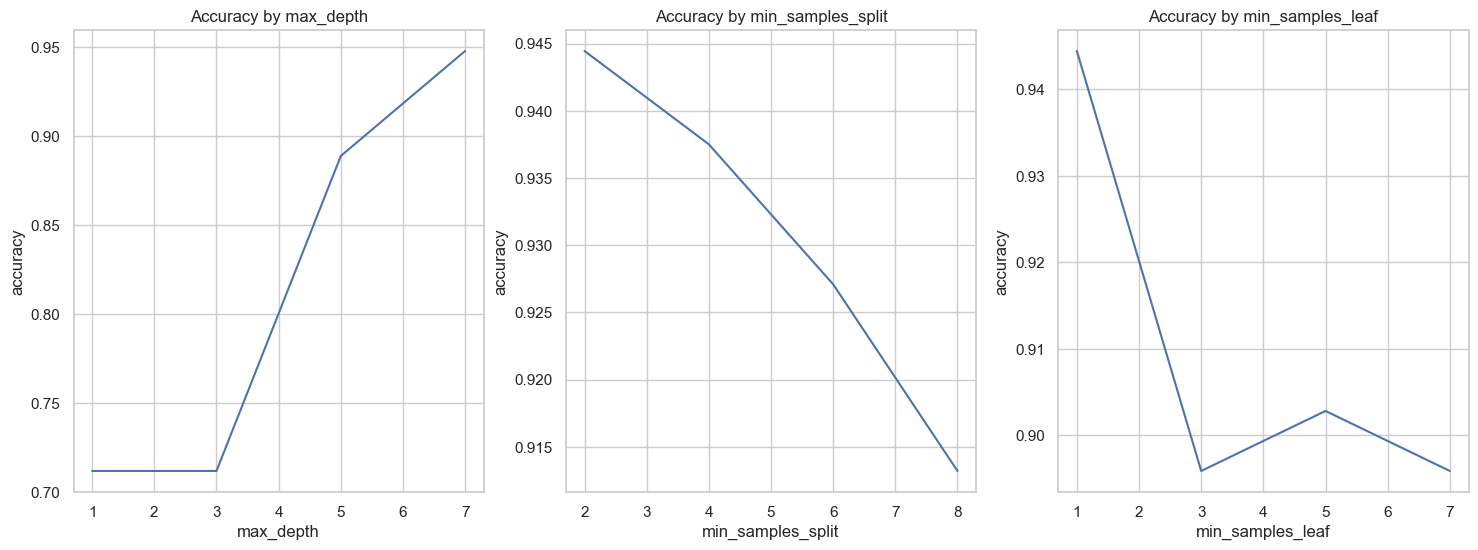

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, param in enumerate(pg):

    accuracy_scores = []
    for value in pg[param]:
        model = DecisionTree(
            feature_types=["categorical"] * X.shape[1],
            **{param: value},
        )
        model.fit(X_train, y_train)
        accuracy_scores.append(
            accuracy_score(y_test, model.predict(X_test))
        )

    axs[i].plot(pg[param], accuracy_scores)
    axs[i].set_title(f"Accuracy by {param}")
    axs[i].set_xlabel(param)
    axs[i].set_ylabel("accuracy")

plt.show()

In [21]:
from sklearn.model_selection import ParameterGrid

pg = {
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [2, 3, 5]
}

parameter_grid = ParameterGrid(pg)

accuracy_scores = []
for parameters in parameter_grid:
    model = DecisionTree(
        feature_types=["categorical"] * X.shape[1],
        **parameters
    )
    model.fit(X_train, y_train)
    accuracy_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

parameter_results = pd.DataFrame(list(parameter_grid))
parameter_results["accuracy"] = accuracy_scores
parameter_results

,max_depth,min_samples_leaf,min_samples_split,accuracy
0,2,2,2,0.701389
1,2,2,4,0.701389
2,2,2,6,0.701389
3,2,3,2,0.701389
4,2,3,4,0.701389
5,2,3,6,0.701389
6,2,5,2,0.701389
7,2,5,4,0.701389
8,2,5,6,0.701389
9,3,2,2,0.711806


# comparison with `sklearn.tree.DecisionTreeClassifier`

In [15]:
def count_cv_on_different_trees(X, y, tree_max_depth, test_size=0.7, random_state=42):

    def append_cv_my(X, y, cv_scores, feature_type, features_count):
        feature_types = [feature_type] * features_count
        model = WrappedDecisionTree(feature_types, max_depth=tree_max_depth)
        cv = cross_val_score(
            model,
            X, y,
            scoring="accuracy",
            cv=10,
            n_jobs=-1,
        )
        cv_scores.append(np.mean(cv))    

    def append_cv_sk(X, y, cv_scores):
        model = DecisionTreeClassifier(max_depth=tree_max_depth)
        cv = cross_val_score(
                model,
                X, y,
                scoring="accuracy",
                cv=10,
                n_jobs=-1,
            )
        cv_scores.append(np.mean(cv)) 
        
    X = OrdinalEncoder().fit_transform(X)
    y = LabelEncoder().fit_transform(y)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_ohe = ohe.fit_transform(X)

    features_count = X.shape[1]
    ohe_features_count = X_ohe.shape[1]

    cv_scores = []    
    
    append_cv_my(X, y, cv_scores, "real", features_count)
    append_cv_my(X, y, cv_scores, "categorical", features_count)
    append_cv_my(X_ohe, y, cv_scores, "real", ohe_features_count)
    append_cv_sk(X, y, cv_scores)
    append_cv_sk(X_ohe, y, cv_scores)

    return cv_scores

In [16]:
cv_results = {}

data = pd.read_csv("agaricus-lepiota.data")
X = data.iloc[:, 1:]
y = data.iloc[:, 0]
cv_results["agaricus-lepiota"] = count_cv_on_different_trees(X, y, 5)

data = pd.read_csv("tic-tac-toe.data")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
cv_results["tic-tac-toe"] = count_cv_on_different_trees(X, y, 5)

data = pd.read_csv("car.data")
X = data.iloc[:, :-1]
y = np.isin(data.iloc[:, -1], ["good", "vgood"])
cv_results["car"] = count_cv_on_different_trees(X, y, 5)

data = pd.read_csv("nursery.data")
X = data.iloc[:, :-1]
y = np.isin(data.iloc[:, -1], ["very_recom", "priority", "spec_prior"])
cv_results["nursery"] = count_cv_on_different_trees(X, y, 5)

columns = [
    "my-label",
    "my-cat",
    "my-ohe",
    "sk-label",
    "sk-ohe"
]
cv_results = pd.DataFrame(cv_results, index=columns)
cv_results

,agaricus-lepiota,tic-tac-toe,car,nursery
my-label,0.970571,0.440406,0.915372,0.999923
my-cat,0.997537,0.487434,0.951818,0.999923
my-ohe,0.998523,0.500066,0.903781,0.999923
sk-label,0.935276,0.745197,0.912603,0.999923
sk-ohe,0.966418,0.727467,0.790439,0.999923
